In [3]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # expose repo root so src/ is importable

import numpy as np
import matplotlib.pyplot as plt

from src.analysis_functions import get_eig_dist
from src.data_functions import plot_eig_dist
import src.simulations as sim_functions
import importlib
importlib.reload(sim_functions)
from src.simulations import (
    generate_gram_hub_matrix,
    simulate_scRNA_data,
    plot_ccdf,
    run_validation,
    validate_gene_expression_distribution,
    validate_cell_expression_distribution,
    validate_dropout_rate,
    validate_count_distribution,
    validate_correlation_structure,
    rho_sweep
)


In [4]:
n_genes = 2000
rho = 0.95
sigma = generate_gram_hub_matrix(n_genes, rho, 1.5, 0.2, seed=31)

(957, 1903)
(1000, 2000)
max ev: 18.936,  above scramble threshold: 16
max scrambled ev: 6.549
non-zero fraction: 0.011


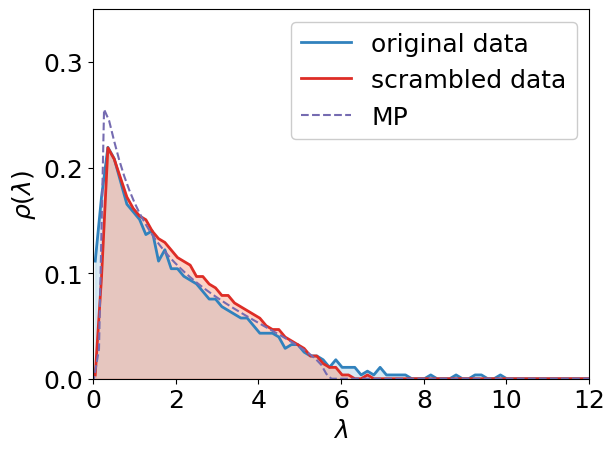

In [12]:
true_counts, observed_counts = simulate_scRNA_data(n_genes=n_genes, sigma=sigma, dropout_rate=0.5)

pcs, pcs1, zero_frac = get_eig_dist(observed_counts, norm=True, log=False, norm_sum=100)
print(observed_counts.shape)
plot_eig_dist(pcs, pcs1, observed_counts.shape[0], 12, 0.35, 80)
print(f'max ev: {np.max(pcs):.3f},  above scramble threshold: {sum(pcs > np.max(pcs1))}')
print(f'max scrambled ev: {np.max(pcs1):.3f}')
print(f'non-zero fraction: {zero_frac:.3f}')
plt.show()

In [13]:
np.save(os.path.join('..','results','simulation_results','raw','simulated_pcs_1.npy'),[pcs,pcs1])

=== Simulation Validation ===

[Expression distribution]
  genes with non-zero expression : 1975
  KS stat vs exponential         : 0.163  (p=3.20e-46)

[Expression distribution]
  genes with non-zero expression : 969
  KS stat vs exponential         : 0.084  (p=2.42e-06)

[Dropout]
  observed zero fraction         : 0.988
  mean detection rate            : 0.012
  expression-detection corr      : 0.970

[Count distributions]
  fraction overdispersed genes   : 0.948

[Correlation structure]
  sigma vs empirical corr (r)    : 0.347
  mean |sigma|                   : 0.0050
  mean |empirical|               : 0.0144


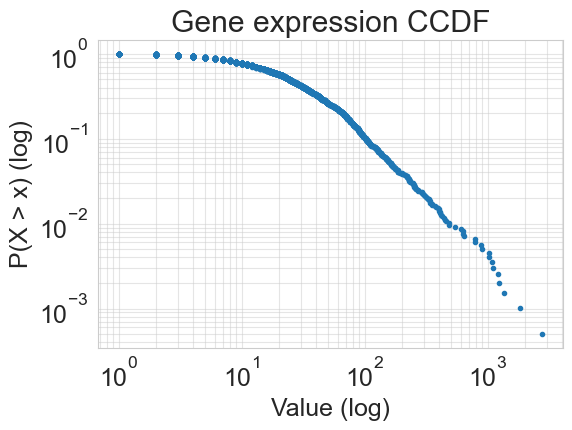

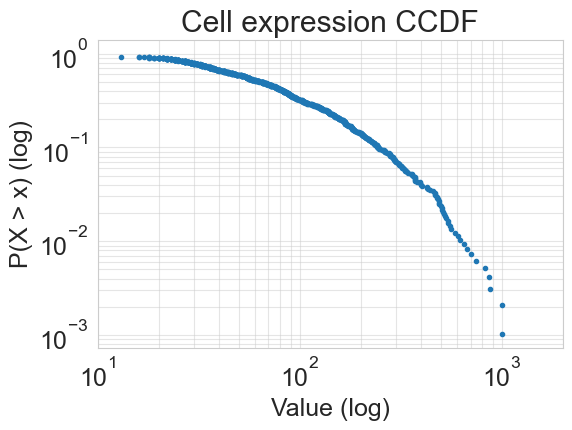

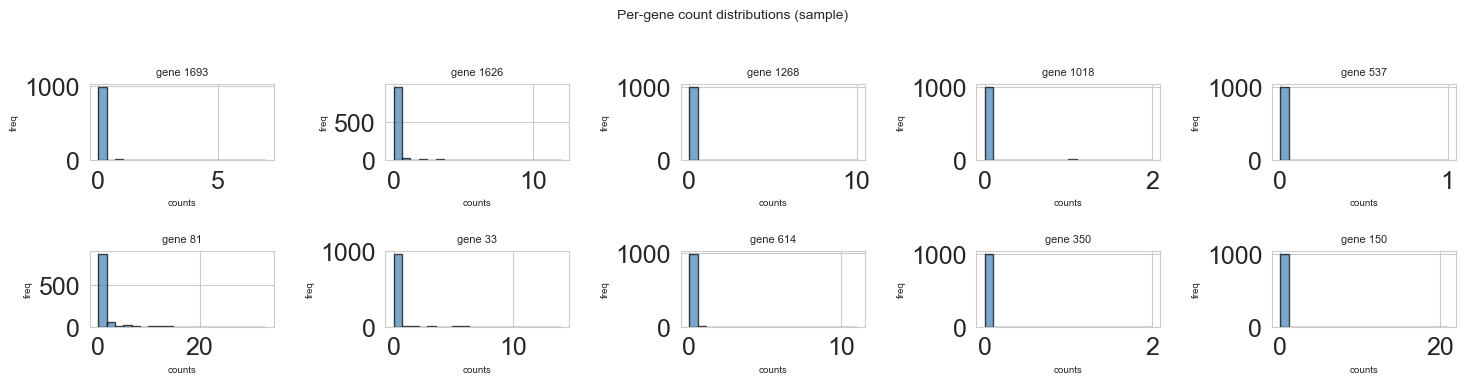

In [30]:
validation_results = run_validation(true_counts, observed_counts, sigma)

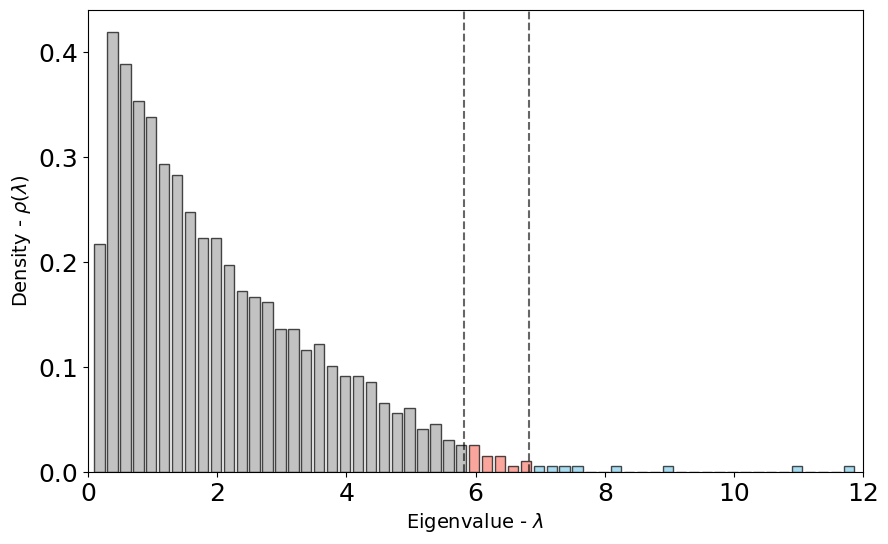

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import os
[pcs,pcs1] = np.load(os.path.join('..','ev_data','simulated_pcs.npy'))
# 1. Generate data
data1 = pcs[pcs>0]
data2 = pcs1[pcs1>0]
bin_width = 0.2
x1 = (1+np.sqrt(2))**2 #MP limit
x2 = np.max(pcs1)

all_data = np.concatenate([data1, data2])
bin_edges = np.arange(min(all_data), max(all_data) + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot Dataset 1 (making bars slightly thinner than the bin width)
n1, bins1, patches1 = ax.hist(data1, bins=bin_edges, width=bin_width*0.8, align='right',
                              edgecolor='black',color='#d9d9d9', alpha=0.7, density=True)

# 3. Plot Dataset 2 (shifting its bin edges forward so they sit side-by-side/overlap)
#n2, bins2, patches2 = ax.hist(data2, bins=bin_edges + (bin_width * 0.5), width=bin_width * 0.5,
#                              edgecolor='black', color='#737373', alpha=0.7, label='Dataset 2')

# 4. Color Dataset 1 (Standard solid colors)
for patch in patches1:
    bin_x = patch.get_x()
    if bin_x < x1:
        patch.set_facecolor('darkgray')
    elif x1 <= bin_x < x2:
        patch.set_facecolor('salmon')
    else:
        patch.set_facecolor('skyblue')


# 6. Add thresholds and layout elements
ax.axvline(x1, color='k', linestyle='--', alpha=0.6)
ax.axvline(x2, color='k', linestyle='--', alpha=0.6)

ax.set_xlabel(r"Eigenvalue - $\lambda$", fontsize=14)
ax.set_ylabel(r"Density - $\rho(\lambda)$", fontsize=14)
ax.set_yticks([0,0.1,0.2,0.3,0.4])
ax.grid(False)
ax.set_xlim([bin_edges[0], bin_edges[-1]+bin_width])
plt.show()

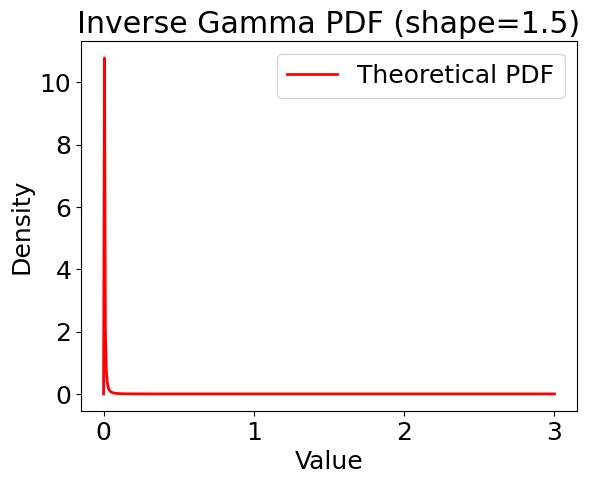

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# Parameters
a = 1.5  # Shape
scale = 0.001
x = np.linspace(0, 3, 500) # Range of x-axis

# Calculate the PDF
pdf = invgamma.pdf(x, a, scale = scale)

plt.plot(x, pdf, 'r-', lw=2, label='Theoretical PDF')
plt.title(f"Inverse Gamma PDF (shape={a})")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

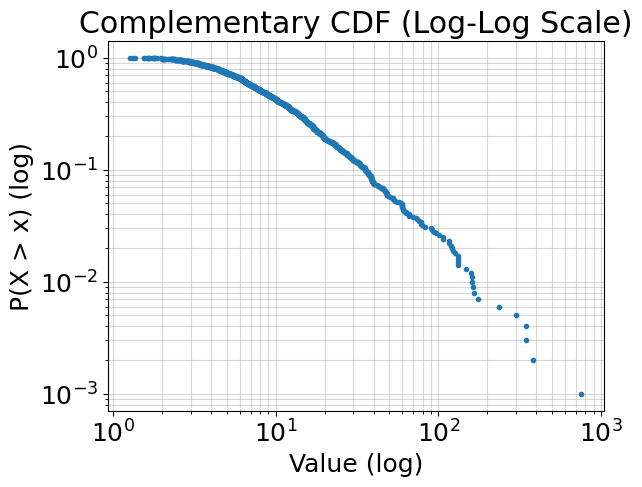

In [7]:
# Simulated gene mean distribution (inverse-Gamma)
rng = np.random.default_rng(0)
gene_mu_samples = 1.0 / rng.gamma(1.5, 1.0 / 0.01, 1000)
plot_ccdf(gene_mu_samples * 1000, label='simulated gene means')
plt.show()

silent genes (total=0): 49 / 2000


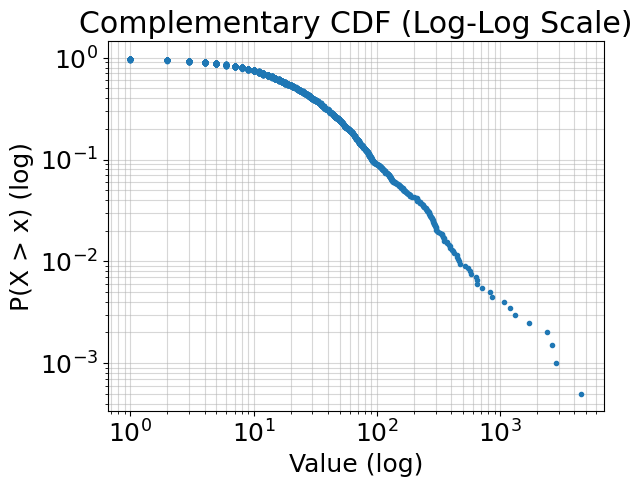

In [8]:
# Observed gene expression CCDF
gene_totals = observed_counts.sum(axis=0)
plot_ccdf(gene_totals, label='observed gene totals')
print(f'silent genes (total=0): {np.sum(gene_totals == 0)} / {len(gene_totals)}')
plt.show()

In [ ]:
import pandas as pd

LOG_FILE    = os.path.join(os.path.dirname(os.getcwd()), 'results', 'simulation_results', 'logs', 'rho_sweep_log.json')
RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'results', 'simulation_results')

# Only the new increments not covered by the original 0.1-step sweep
new_rho_values = [0.0, 0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.0]

new_results = rho_sweep(
    rho_values=new_rho_values,
    n_cells=1000,
    n_genes=2000,
    dropout_rate=1,
    shape=1.5,
    hub_probability=0.2,
    n_repeats=10,
    seed=31,
    log_file=LOG_FILE,
)

# Merge with original results and sort
original_results = pd.read_csv(os.path.join(RESULTS_DIR, 'raw', 'rho_sweep_raw.txt'), sep='\t')
sweep_results = pd.concat([original_results, new_results], ignore_index=True).sort_values(['rho', 'repeat']).reset_index(drop=True)

# rep=2 corresponds to count_seed=33, a persistent outlier across all rho values
sweep_clean = sweep_results[sweep_results['repeat'] != 2]
summary = sweep_clean.groupby('rho')['gmp_cor'].agg(['median', 'std']).round(3)
print(summary)

# Overwrite raw results and summary with merged data
sweep_results.to_csv(os.path.join(RESULTS_DIR, 'raw', 'rho_sweep_raw.txt'), sep='\t', index=False)
with open(os.path.join(RESULTS_DIR, 'raw', 'rho_sweep_summary.txt'), 'w') as f:
    f.write('# GMP-Cor calibration sweep (rep=2 / count_seed=33 excluded)\n')
    f.write('# n_cells=1000  n_genes=2000  dropout_rate=1  shape=1.5  hub_probability=0.2  sigma_seed=31\n')
    f.write(summary.to_string())
    f.write('\n')
print(f'Results saved to {RESULTS_DIR}')

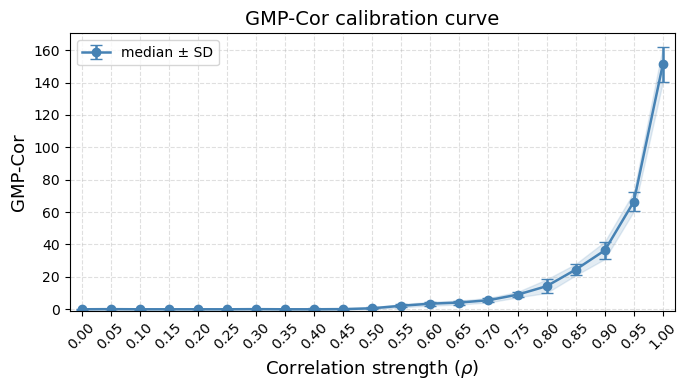

In [5]:
# Calibration curve: GMP-Cor vs. correlation strength (rho)
import pandas as pd
import os
import matplotlib.pyplot as plt
RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'results', 'simulation_results')
summary = pd.read_csv(os.path.join(RESULTS_DIR, 'raw', 'rho_sweep_summary.txt'),
                      sep=r'\s+', comment='#', index_col=0)

rho_vals = summary.index.values
medians  = summary['median'].values
stds     = summary['std'].values

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(rho_vals, medians, yerr=stds, fmt='o-', color='steelblue',
            capsize=4, linewidth=1.8, markersize=6, label='median ± SD')
ax.fill_between(rho_vals, medians - stds, medians + stds, alpha=0.15, color='steelblue')
ax.set_xlabel(r'Correlation strength ($\rho$)', fontsize=13)
ax.set_ylabel('GMP-Cor', fontsize=13)
ax.set_title('GMP-Cor calibration curve', fontsize=14)
ax.set_xticks(rho_vals)
ax.tick_params(axis='x', rotation=45)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(bottom=-1)
ax.grid(True, linestyle='--', alpha=0.2)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'rho_sweep_calibration.svg'), dpi=150)
plt.show()